In [1]:
#imports
import sys
sys.path.append("../../src")
# A collection of handy imports. Not that important.
from project_imports import * 
import numerical_quenches as nq
from numerical_quenches import g_linear_hold

#These imports will be used to calculate projectors
import kibble_zurek as kz
import time_evolved_z_correlators as zz



In [3]:
def running_average_after_x0(x, data, x0):
    mask = x >= x0
    x_sel = x[mask]
    y_sel = data[mask]

    cumsum = np.cumsum(y_sel)
    running_avg = cumsum / np.arange(1, len(y_sel) + 1)

    cutoffs = x_sel  # ordered x cutoffs corresponding to each average
    return running_avg, cutoffs


In [4]:
#Define Sudden quench protocol
def g_sudden_quench(t,args):
    g0,gf,t0 = args
    if t<t0:
        return g0
    else:
        return gf
#Critical Times of DQPTs
def critical_times(gf,n):
    ek = 2*sqrt(gf**2+1)
    n_plot = np.arange(0,n)
    tns = (n_plot+1/2)*pi/ek
    return tns
def est_z_defects(tau,n):
    numerator = n*n+n
    denom = 2**(n-1)*4*pi*sqrt(2*tau)
    return numerator/denom
def est_x_defects(tau,n):
    numerator = n-1
    denom = 4*pi*sqrt(2*tau)
    return numerator/denom



In [5]:
###
#Params
###
L=100 #Length
g0 = 2 #Initial Field
gf = 0.00 #Final Field
quench_times = [0.0001,0.01,1,2.5,5,10,100,1000] #Quench times
ns = [1,2,3,4,6,7,8,9]

#####

t_c = critical_times(gf,1)[0] #DQPT timescale from sudden quench. t_c(2n+1) mark the LE non-analytic cusps



In [6]:

#masks = [(t_plot >= 0) & (t_plot <= ti ) for ti in t_cutoffs] #If the old one is unececssary so is this

slow_protocol_states=[]
sudden_protocol_states=[]
#Main Loop
for quench_time in quench_times:
    ####g= 1- t/tau
    t_start = quench_time*(1-g0)
    t_quench_end = quench_time*(1-gf)

    t_quench_evolution= np.linspace(t_start,t_quench_end,25,endpoint=False)
    t_free_evolution = np.linspace(t_quench_end,t_quench_end+t_c*10,200)
    t_eval = np.concatenate((t_quench_evolution ,t_free_evolution  ))
    t_plot = (t_eval -t_quench_end)

    slow_args = [quench_time,t_quench_end]
    sudden_args=[g0,gf,t_quench_end]
    #Generate States
    print("Generating States")
    slow_states = nq.states(L,t_eval,g_linear_hold,slow_args)
    sudden_states= nq.states(L,t_eval,g_sudden_quench,sudden_args)

    #Appending
    slow_protocol_states.append(slow_states)
    sudden_protocol_states.append(sudden_states)
#Now we have all the states.




Generating States
g0=2.0
g0=2
Generating States
g0=2.0
g0=2
Generating States
g0=2.0
g0=2
Generating States
g0=2.0
g0=2
Generating States
g0=2.0
g0=2
Generating States
g0=2.0
g0=2
Generating States
g0=2.0
g0=2
Generating States
g0=2.0
g0=2


In [7]:
PZN_slow_data=[]
z_ns = array([1,2,3,4,5,6,7])

#PZN_sudden_data=[]
for slow_state, sudden_state, tau in zip(slow_protocol_states,sudden_protocol_states,quench_times):
    print(tau)
    x = array([[zz.P_n(n,s) for s in slow_state] for n in z_ns])
    PZN_slow_data.append(x)


0.0001


/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/Numerical Quenches/../../src/time_evolved_z_correlators.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)


0.01
1
2.5
5
10
100
1000


In [8]:
PXN_slow_data=[]
PXN_sudden_data=[]
x_ns = [2,3,4,5,6,7,8]
for slow_state, sudden_state, tau in zip(slow_protocol_states,sudden_protocol_states,quench_times):
    print(tau)
    x = array([[kz.P_n(n,s) for s in slow_state] for n in x_ns])
    PXN_slow_data.append(x)
    x = array([[kz.P_n(n,s) for s in sudden_state] for n in x_ns])
    PXN_sudden_data.append(x)


0.0001
0.01
1
2.5
5
10
100
1000


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_35397/4216549535.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend()


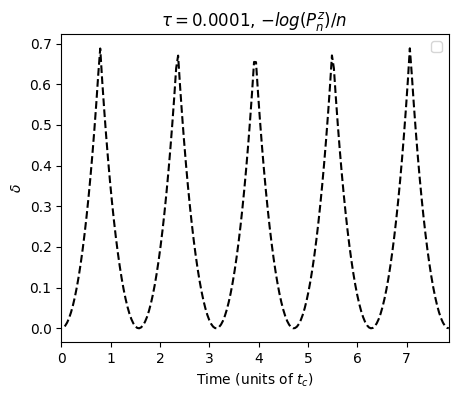

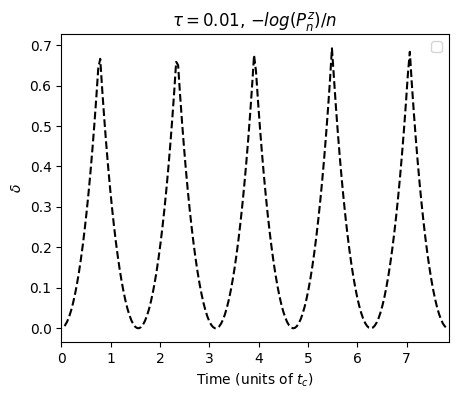

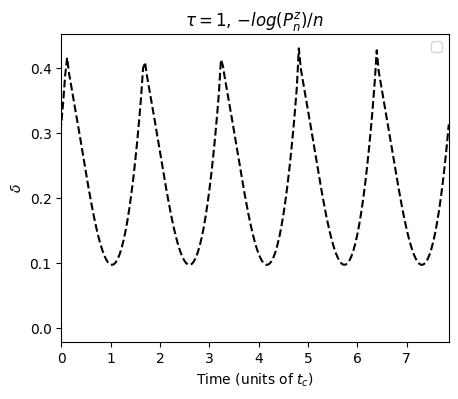

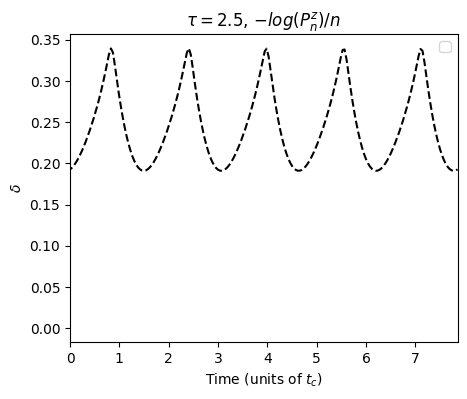

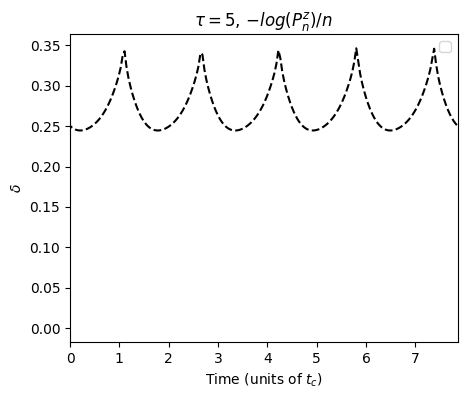

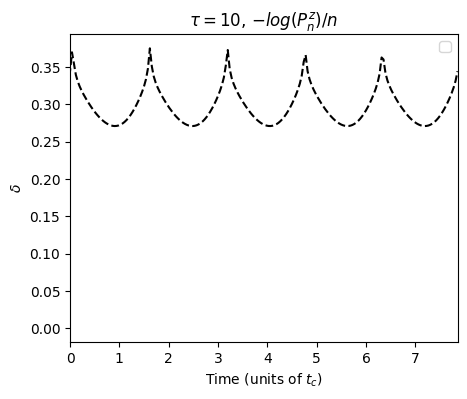

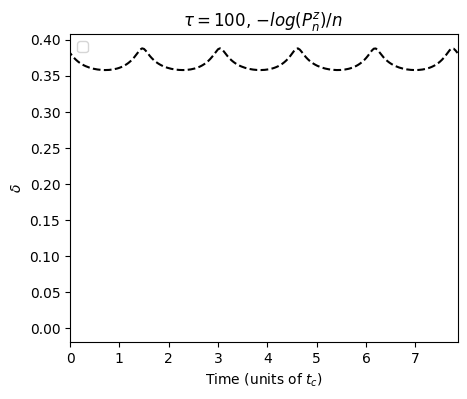

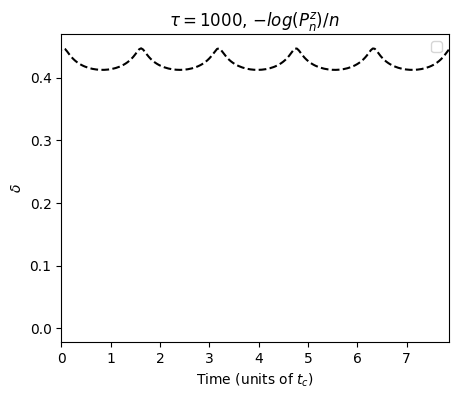

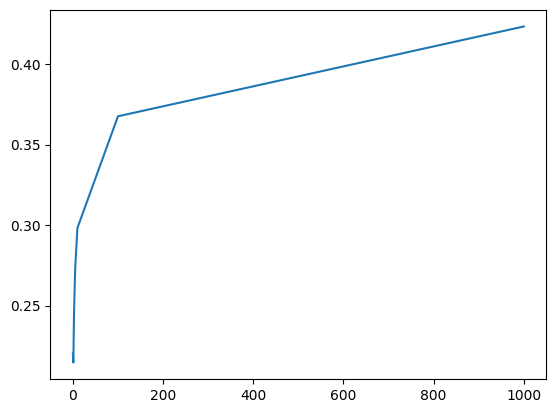

In [21]:
plot(quench_times,avgs)


n=1, 0.06281572928128334
n=2, 0.06424777570435947
n=3, 0.0648949957615168
n=4, 0.065255743778632
n=5, 0.06546735902442806
n=6, 0.06560410569207184
n=7, 0.06570161628149596
n=1, 0.06279161562779045
n=2, 0.06422542850083227
n=3, 0.06487340216908741
n=4, 0.06523458583532613
n=5, 0.06544647149629562
n=6, 0.06558339390525207
n=7, 0.06568102734214938
n=1, 0.021018070918434606
n=2, 0.02181136088544658
n=3, 0.022568299631412297
n=4, 0.023440834234677382
n=5, 0.024209658132663042
n=6, 0.024738174232734583
n=7, 0.02510172491419163
n=1, 0.016548357848714446
n=2, 0.015087469428606254
n=3, 0.014334273678415888
n=4, 0.01403741713955628
n=5, 0.013946764397682831
n=6, 0.013947323542561396
n=7, 0.013983352014777073
n=1, 0.017697307083404834
n=2, 0.01637238341036029
n=3, 0.01531554762285614
n=4, 0.014672809260588393
n=5, 0.014322065054869243
n=6, 0.014144576032515871
n=7, 0.014061660900789724
n=1, 0.019317344976332806
n=2, 0.01853360915710317
n=3, 0.017637307869946217
n=4, 0.016963470748839138
n=5, 0.01

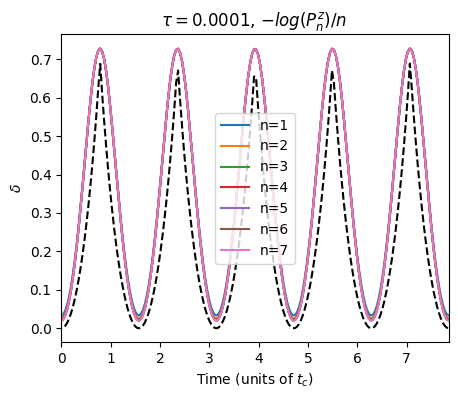

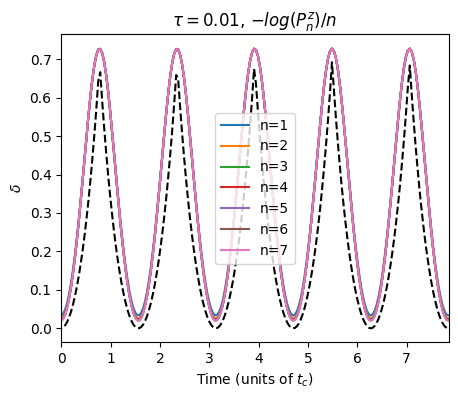

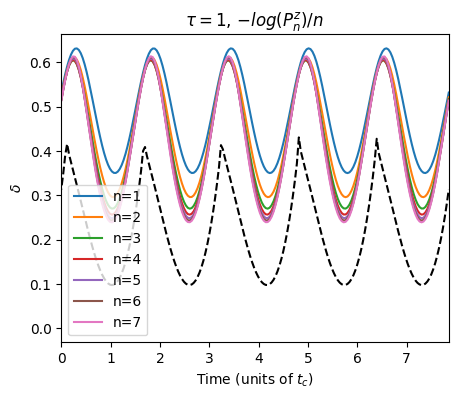

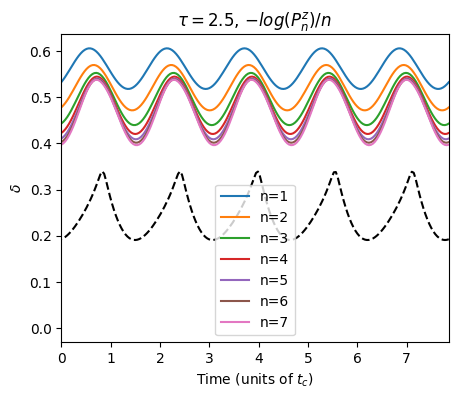

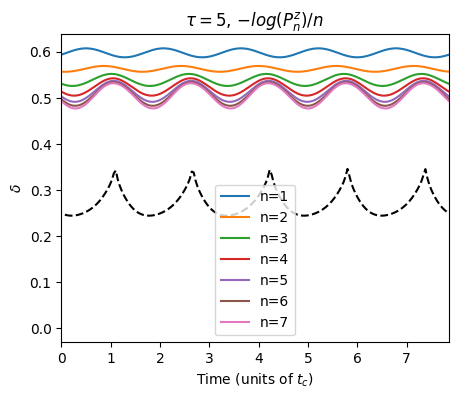

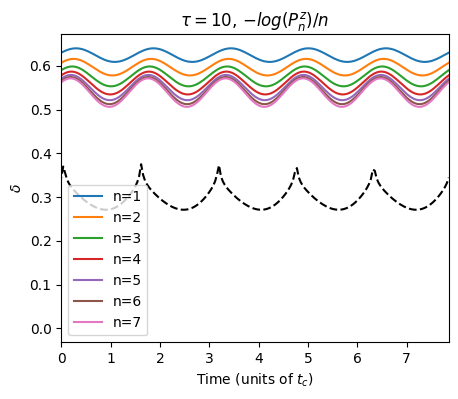

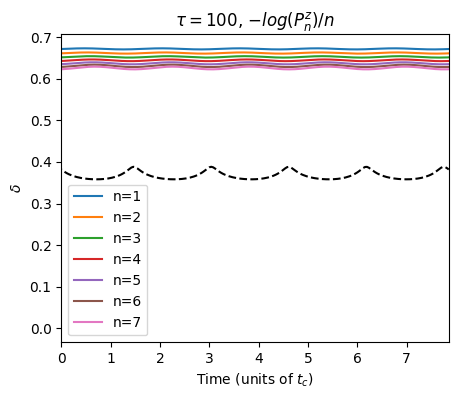

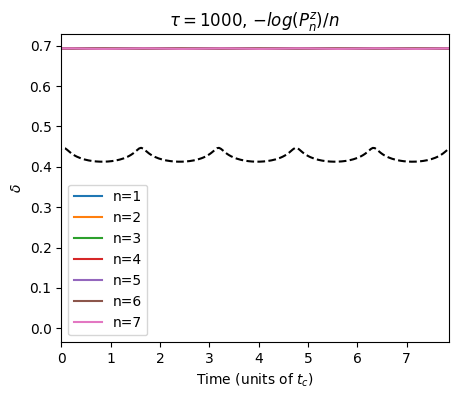

In [9]:
for PZN_slow,PZN_sudden, tau,state in zip(PZN_slow_data,PZN_slow_data,quench_times,slow_protocol_states):
    plt.figure(figsize=(5,4))
    for x,y,n in zip(PZN_slow,PZN_sudden,z_ns):
        kz_avgs,cut_off_times = running_average_after_x0(t_eval,x,t_quench_end)
        kz_defects = abs(1/2**n-kz_avgs)
        ###
        sudden_avgs,cut_off_times = running_average_after_x0(t_eval,y,t_quench_end)
        sudden_defects = abs(1/2**n-sudden_avgs)
        ###
        plotting_times= (cut_off_times-t_quench_end)/t_c
        plot( t_plot ,-log(x)/n,label=f"n={n}")
        beta = -log(x)/n
        print(f"n={n}, {np.average(beta*beta)-np.average(beta)**2}")
        #plot(t_plot,-log(y)/n)
        #plt.hlines(est_z_defects(tau,n),plotting_times[0],plotting_times[-1])
        #scatter(plotting_times ,kz_defects,s=5)
    plot(t_plot,-log(nq.overlap(state,nq.groundstate(2,L)))/L,"--k"  )
    title(fr"$\tau=${tau}, $ -log(P^z_n)/n$ ")
    xlabel(r"Time (units of $t_c$)")
    ylabel(r"$\delta$")
    xlim(0,t_plot[-1])
    legend()
    #yscale("log")
    #show()

n=2, 2.3363771343605655e-20
n=4, 9.619490561268263e-05
n=6, 0.0002576817101061503
n=8, 0.00040889118414338374
n=10, 0.0005390883437518672


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


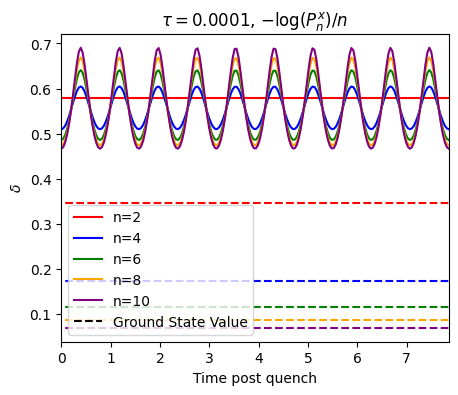

n=2, 2.3339252713478276e-12
n=4, 9.604592668306005e-05
n=6, 0.00025734613013350373
n=8, 0.0004084093533427934
n=10, 0.0005384942223719865


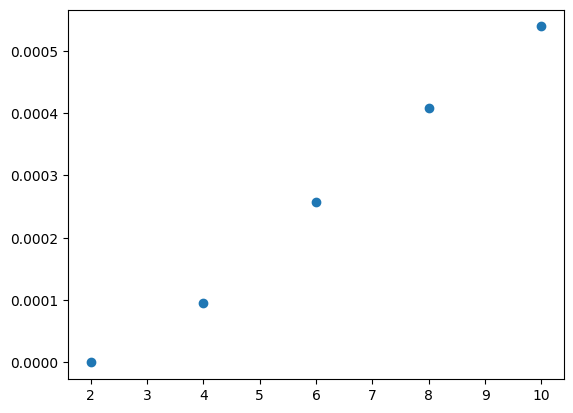

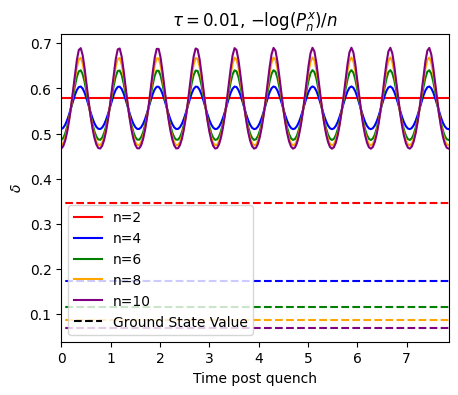

n=2, 4.894635612826654e-06
n=4, 9.496287619469306e-06
n=6, 1.1973020842749905e-05
n=8, 1.584730023748658e-05
n=10, 2.157923365750167e-05


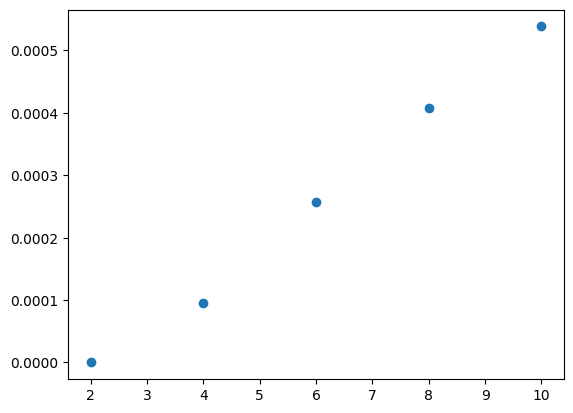

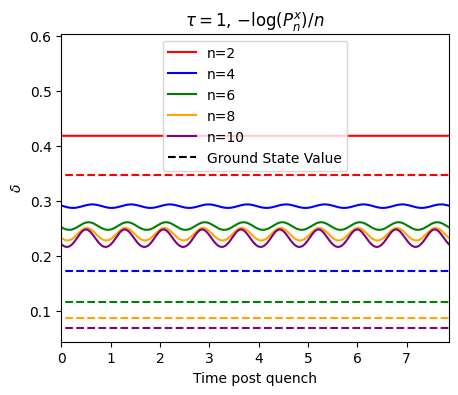

n=2, 7.872473139657963e-06
n=4, 1.5837478047308262e-05
n=6, 1.8463335554901488e-05
n=8, 1.985334213573557e-05
n=10, 2.1165764113186307e-05


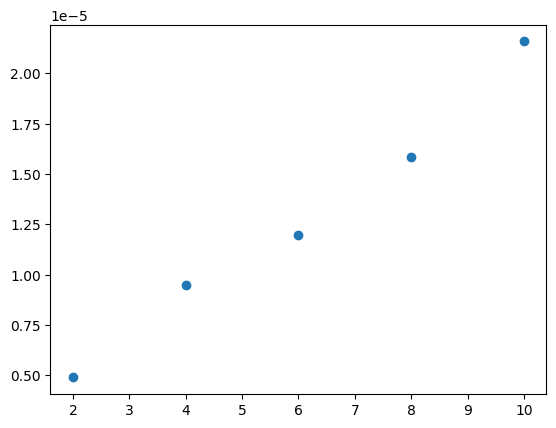

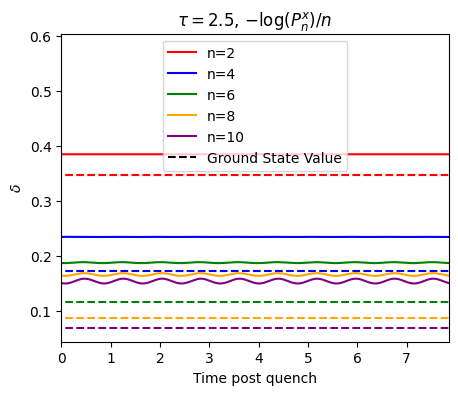

n=2, 9.44763175259828e-06
n=4, 1.9787611354048083e-05
n=6, 2.352770287508895e-05
n=8, 2.5308385786180303e-05
n=10, 2.6344798432098442e-05


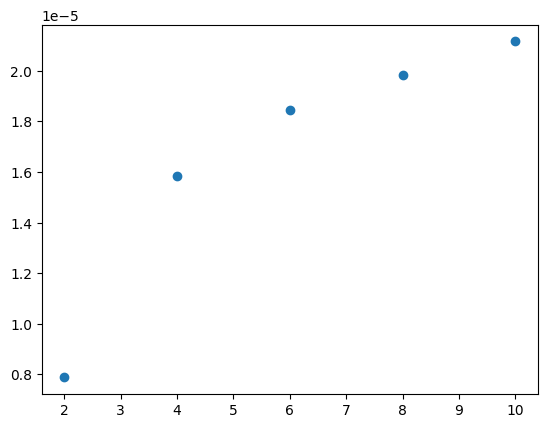

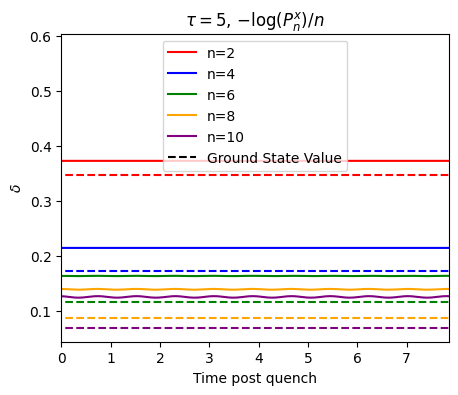

n=2, 1.0580603135687512e-05
n=4, 2.27702903234128e-05
n=6, 2.7440121064276573e-05
n=8, 2.9759641933506278e-05
n=10, 3.10868730116681e-05


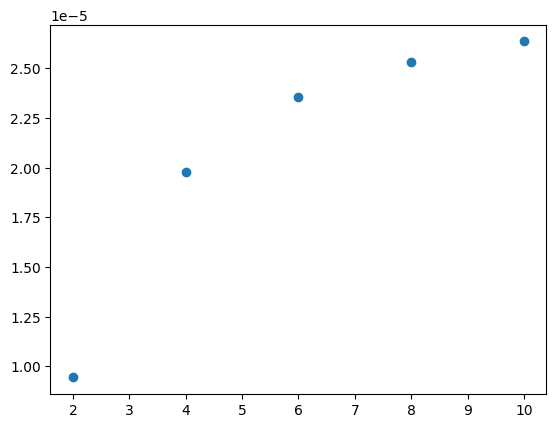

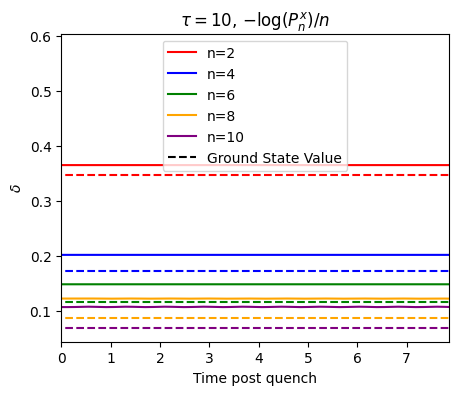

n=2, 1.264937247361195e-05
n=4, 2.8043561094316384e-05
n=6, 3.436132732864073e-05
n=8, 3.774141555493267e-05
n=10, 3.984235935355295e-05


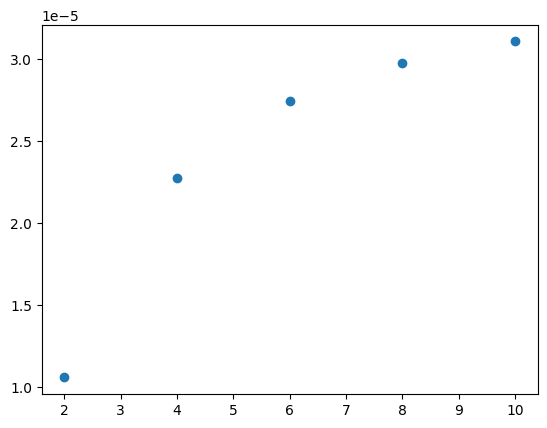

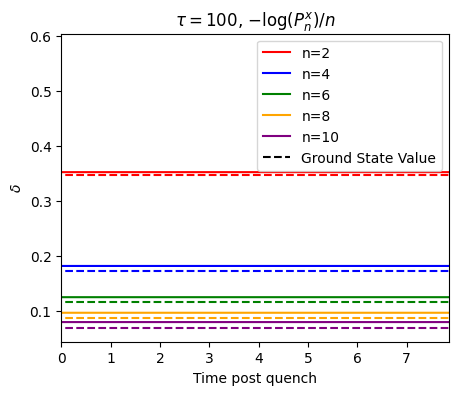

n=2, 1.3841149596064638e-05
n=4, 3.087238019760473e-05
n=6, 3.787532635083887e-05
n=8, 4.1623235691386876e-05
n=10, 4.396064590497608e-05


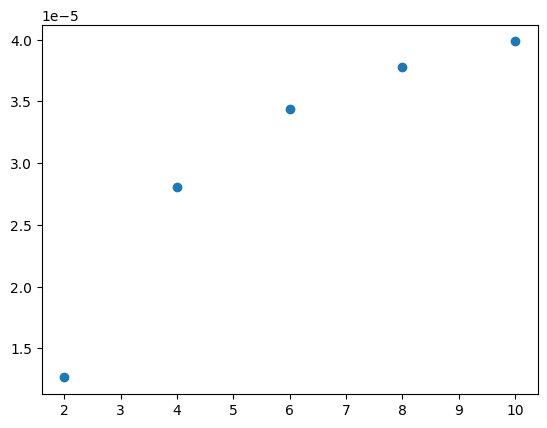

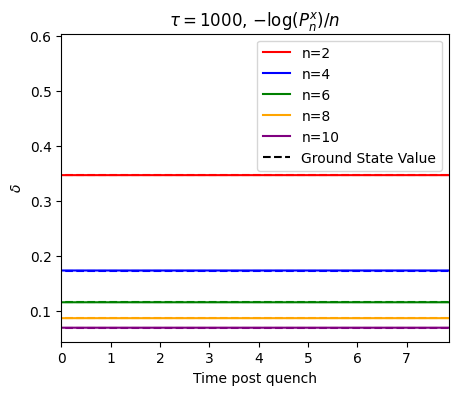

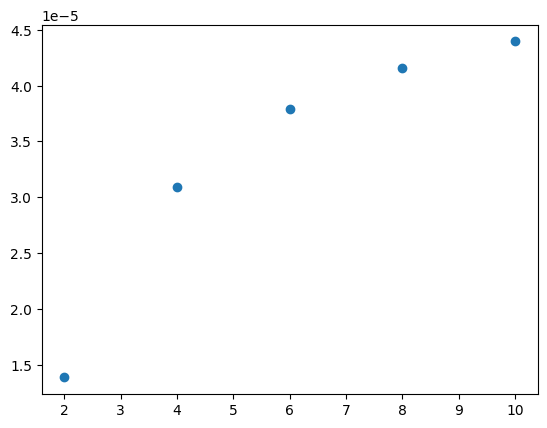

In [423]:
for PN_slow,PN_sudden, tau in zip(PXN_slow_data,PXN_sudden_data,quench_times):
    plt.figure(figsize=(5,4))
    dat=[]
    for x,y,n,c in zip(PN_slow,PN_sudden,ns,colors):
        kz_avgs,cut_off_times = running_average_after_x0(t_eval,x,t_quench_end)
        kz_defects = abs(1/2-kz_avgs)
        ###
        sudden_avgs,cut_off_times = running_average_after_x0(t_eval,y,t_quench_end)
        sudden_defects = abs(1/2-sudden_avgs)
        ###
        plotting_times= (cut_off_times-t_quench_end)/t_c
        plot( t_plot ,-log(x)/n ,label=f"n={n}",color=c)
        plt.hlines(-log(1/2)/n,t_plot[0],t_plot[-1],color=c,ls="--")
        #scatter( t_plot ,-log(y)   ,label=f"n={n}",s=5)
        beta = np.gradient(-log(x)/n)
        print(f"n={n}, {np.var(beta)}")
        dat.append(np.var(beta))

        #scatter( t_plot ,abs((est_x_defects(tau,n)-abs(1/2-x))),s=4)

        #scatter(plotting_times ,kz_defects,s=5)
    #ylim(0,.05)
    title(fr"$\tau=${tau}, $ -\log(P^x_n)/n$")
    xlabel(r"Time post quench")
    ylabel(r"$\delta$")
    #yscale("log")
    plt.hlines(-log(1/2)/n,t_plot[0],t_plot[1],color="black",ls="--",label="Ground State Value")

    legend()
    xlim(0,t_plot[-1])
    show()
    scatter(ns,dat)

In [403]:
colors = ["red","blue","green","orange","purple"]

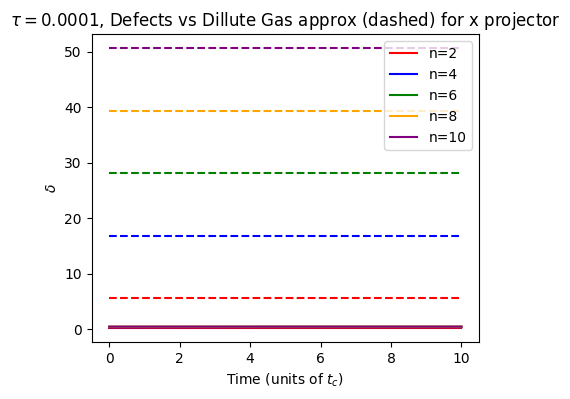

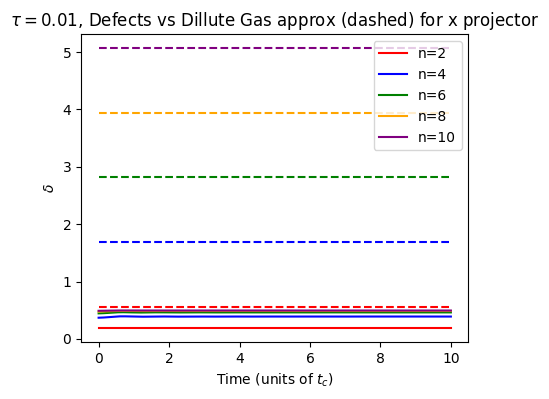

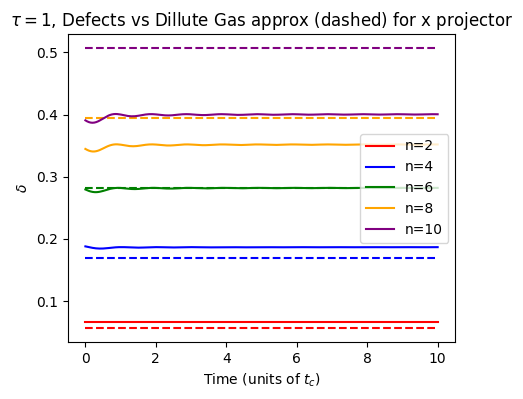

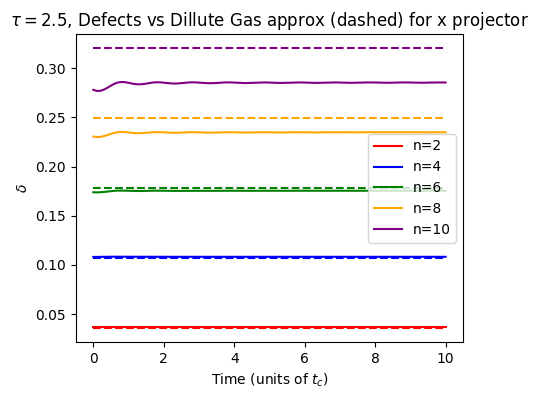

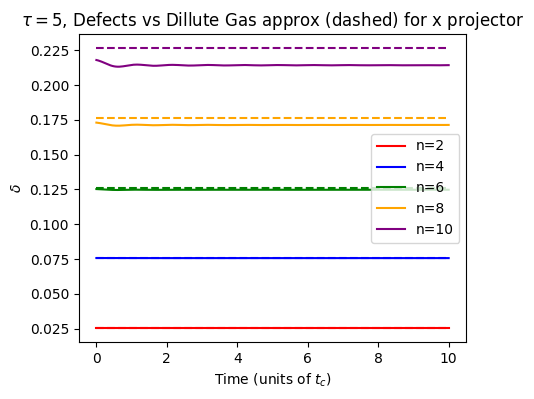

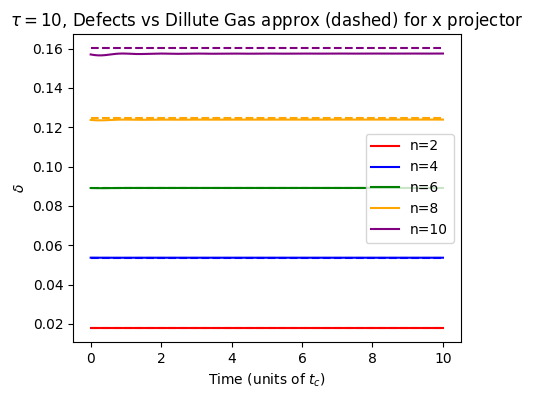

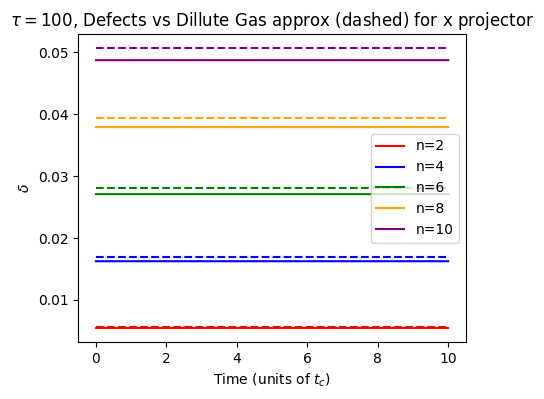

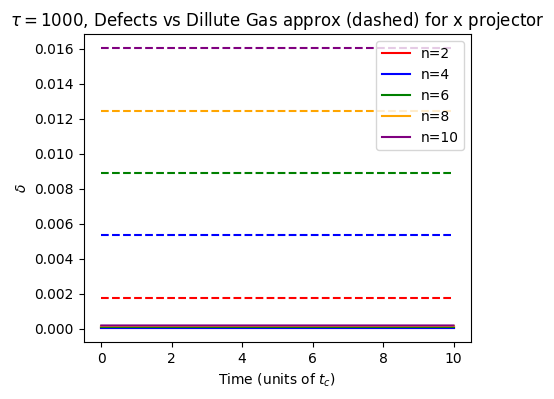

In [406]:
for PN_slow,PN_sudden, tau in zip(PXN_slow_data,PXN_sudden_data,quench_times):
    plt.figure(figsize=(5,4))
    for x,y,n,c in zip(PN_slow,PN_sudden,ns,colors):
        kz_avgs,cut_off_times = running_average_after_x0(t_eval,x,t_quench_end)
        kz_defects = abs(1/2-kz_avgs)
        ###
        sudden_avgs,cut_off_times = running_average_after_x0(t_eval,y,t_quench_end)
        sudden_defects = abs(1/2-sudden_avgs)
        ###
        plotting_times= (cut_off_times-t_quench_end)/t_c
        plot( plotting_times ,kz_defects,label=f"n={n}",color=c)
        plot(plotting_times,est_x_defects(tau,n)*np.ones(len(plotting_times)),"--",color=c)
        #scatter( t_plot ,abs((est_x_defects(tau,n)-abs(1/2-x))),s=4)

        #scatter(plotting_times ,kz_defects,s=5)
    #ylim(0,.05)
    title(fr"$\tau=${tau}, Defects vs Dillute Gas approx (dashed) for x projector ")
    xlabel(r"Time (units of $t_c$)")
    ylabel(r"$\delta$")
    #yscale("log")
    legend()
    #xlim(0,t_plot[-1])
    show()

# Diagonostic 


In [192]:
est_z_defects(1,2)

np.float64(0.1688093092794574)

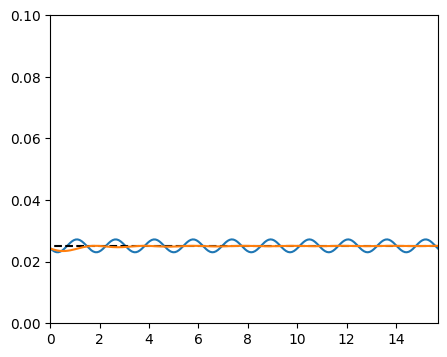

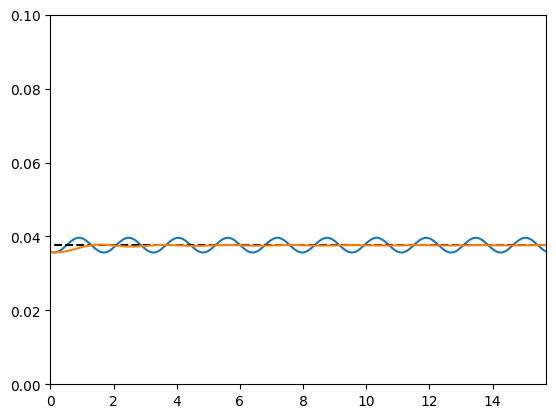

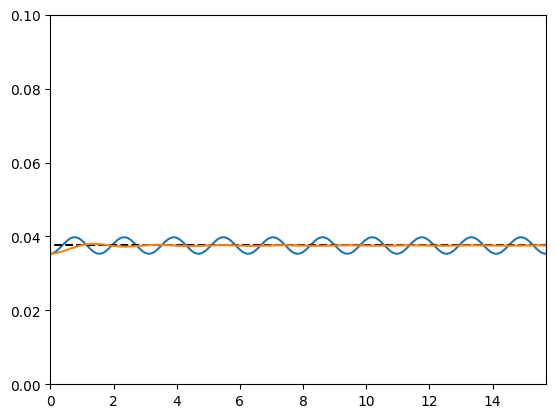

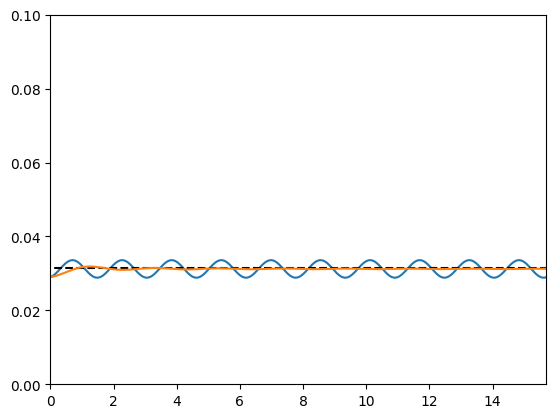

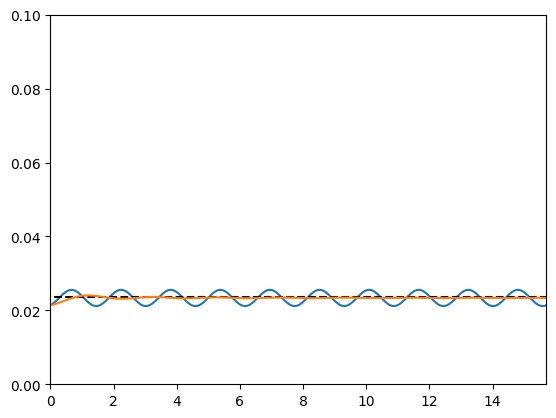

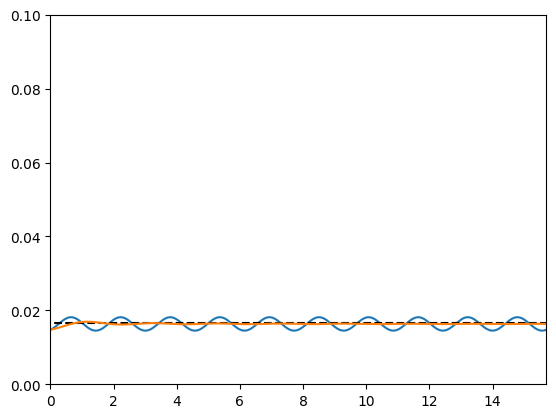

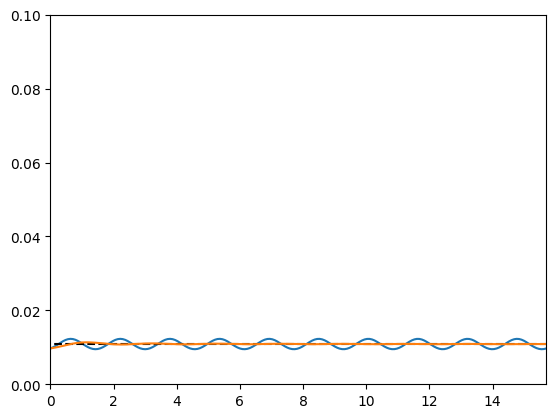

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_21567/375624201.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend()


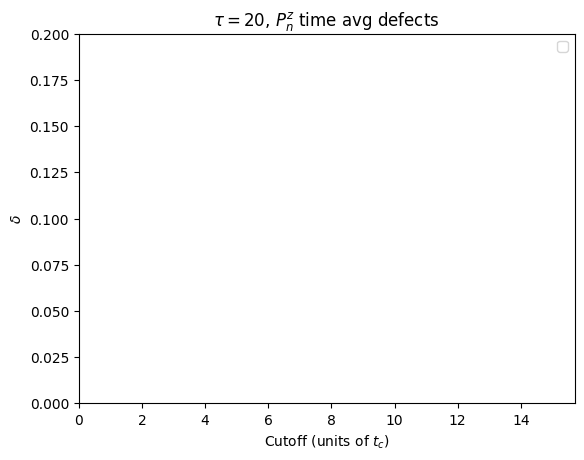

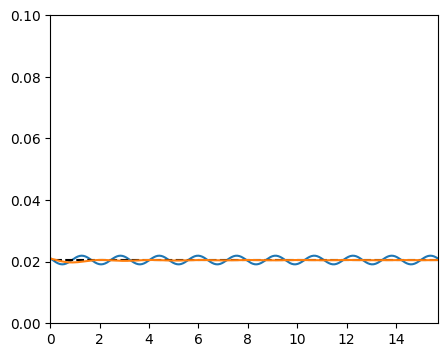

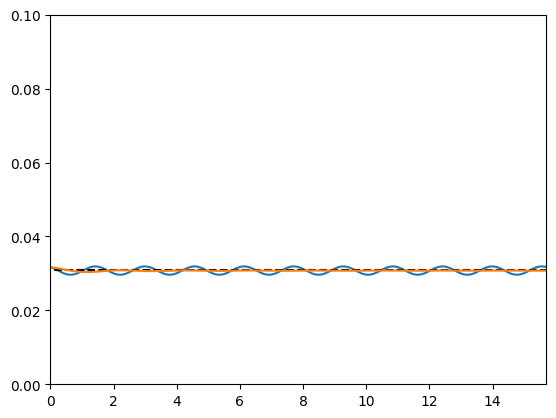

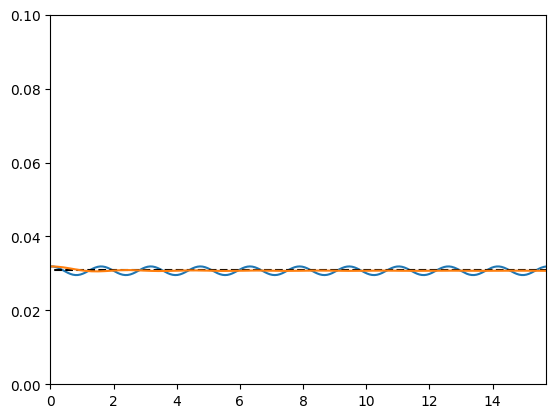

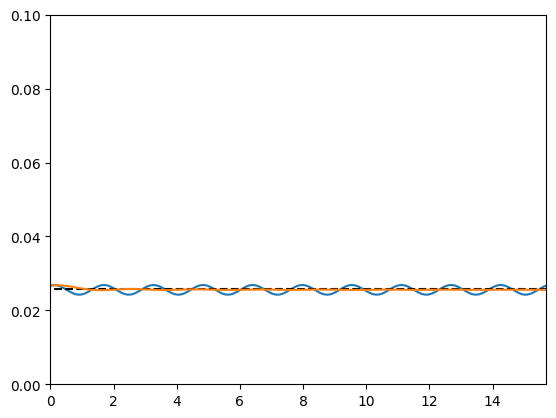

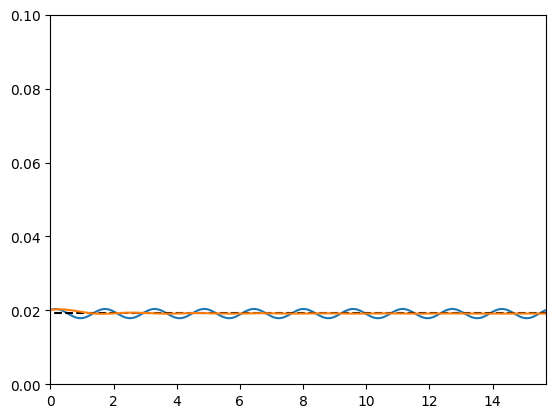

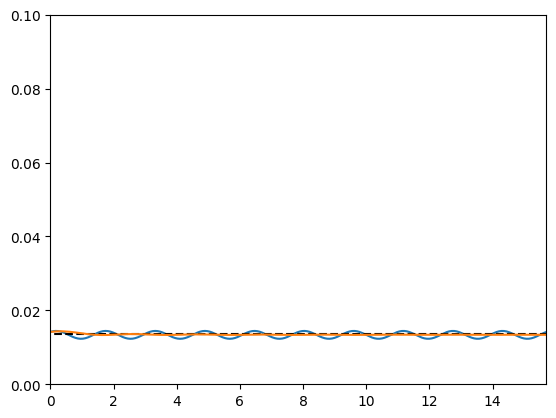

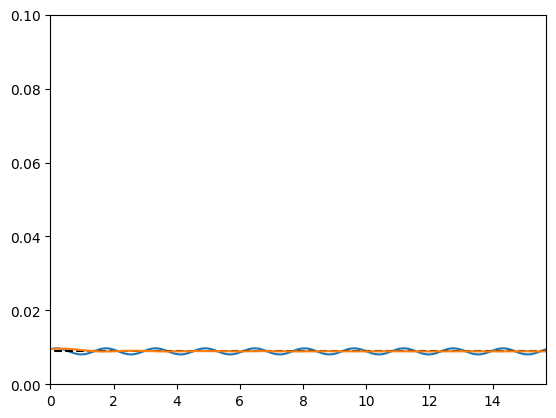

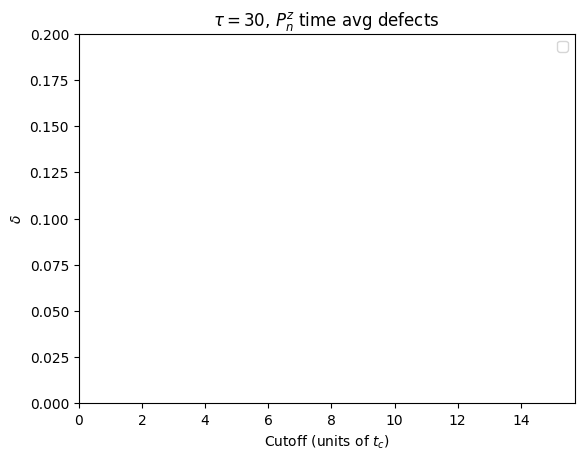

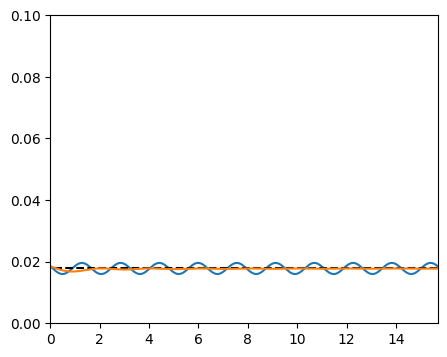

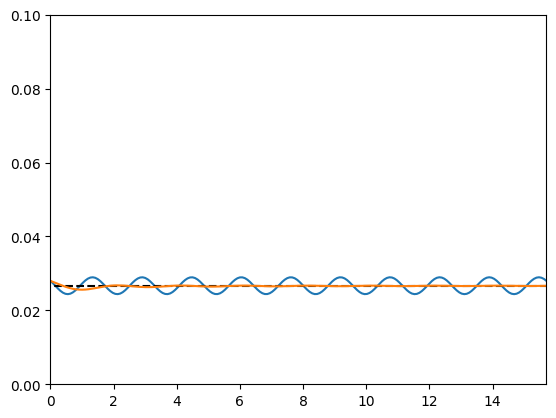

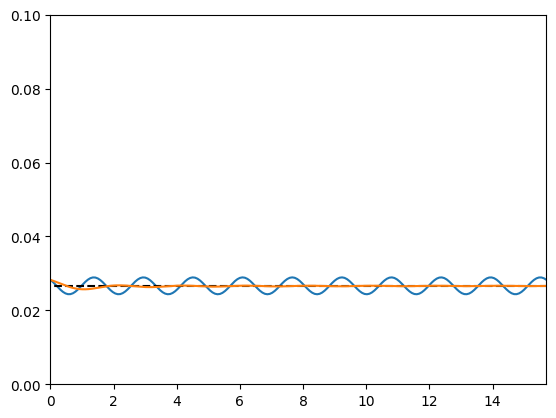

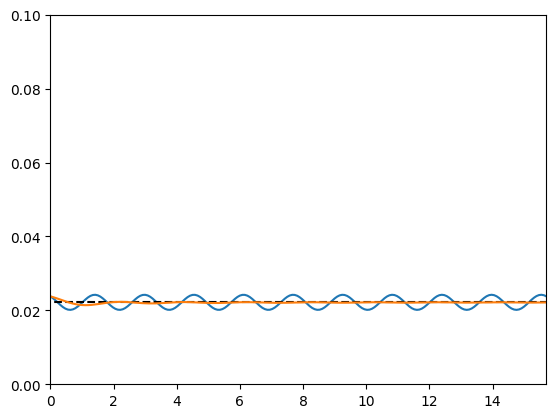

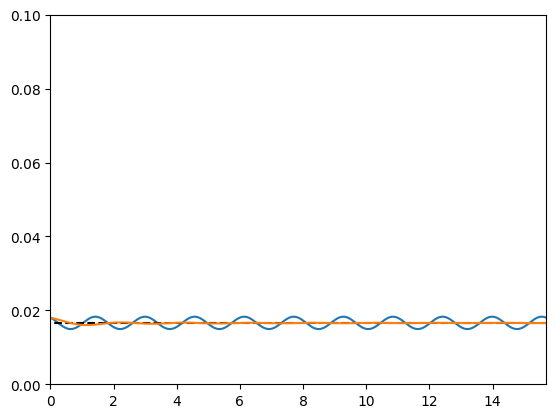

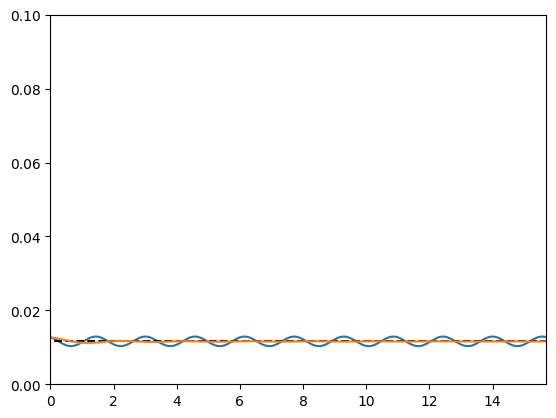

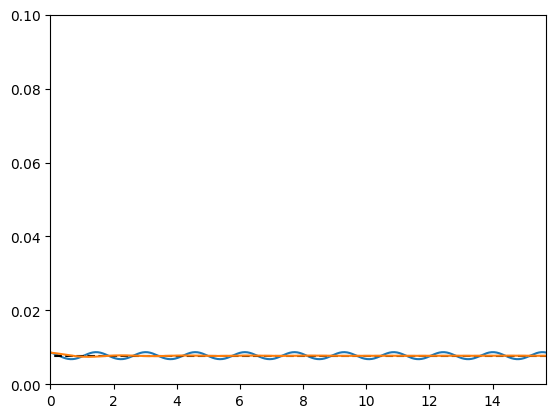

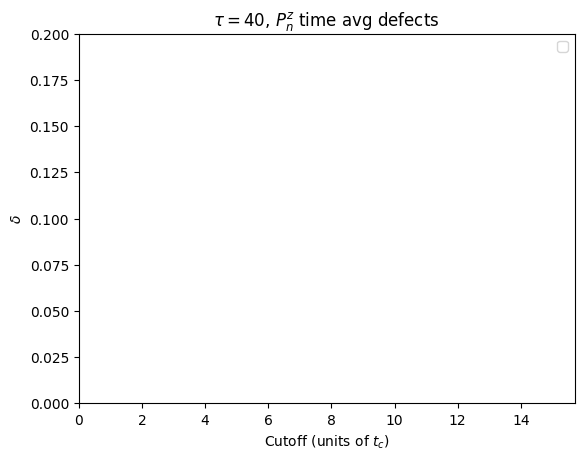

In [200]:
for PZN_slow,PZN_sudden, tau in zip(PZN_slow_data,PZN_sudden_data,quench_times):
    plt.figure(figsize=(5,4))
    for x,y,n in zip(PZN_slow,PZN_sudden,ns):
        plot(t_plot,abs(1/2**n-x))
        plt.hlines(est_z_defects(tau,n),t_plot[0],t_plot[-1],color="black",ls="--")
        kz_avgs,cut_off_times = running_average_after_x0(t_eval,x,t_quench_end)
       # print(kz_avgs)
        kz_defects = abs(1/2**n-abs(kz_avgs))
       # print(kz_defects)
        #print(np.average(1/2**n-x))
        # ###
        # sudden_avgs,cut_off_times = running_average_after_x0(t_eval,y,t_quench_end)
        # sudden_defects = abs(1/2**n-sudden_avgs)
        # ###
        # plotting_times= (cut_off_times-t_quench_end)/t_c
        plot( plotting_times ,abs(kz_defects))
        xlim(0,t_plot[-1])
        ylim(0,.1)

        show()
        # #scatter(plotting_times ,kz_defects,s=5)
    title(fr"$\tau=${tau}, $ P^z_n$ time avg defects ")
    xlabel(r"Cutoff (units of $t_c$)")
    ylabel(r"$\delta$")
    legend()
    xlim(0,t_plot[-1])
    ylim(0,.2)
    show()

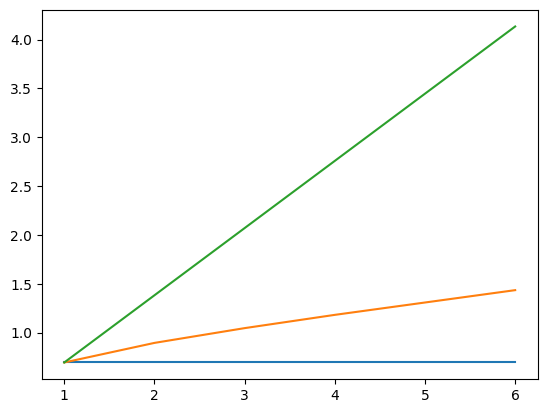

In [301]:
import kblock_ising_model as kb
gs = [0,1,100]
for g in gs:
    k = kb.k_vals(L)
    U = kb.U(kb.k_vals(L),g)
    testing=array([-log(kb.P_n(ni,U,k)) for ni in ns])
    plot(ns,testing)

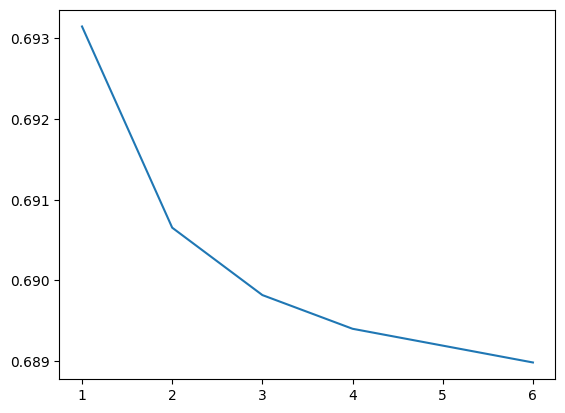

In [363]:
li_taus = np.logspace(-1,2,30)
test = [kz.state(L,tau_i,tau_i)  for tau_i in quench_times]


In [369]:

lilah = array([1/2-kz.P_n(2,s) for s in test])

kristian = array([1/2-kz.P_n(8,s) for s in test])

In [370]:
kz.P_n(2,test[-1])

np.complex128(0.49997968522323755+0j)

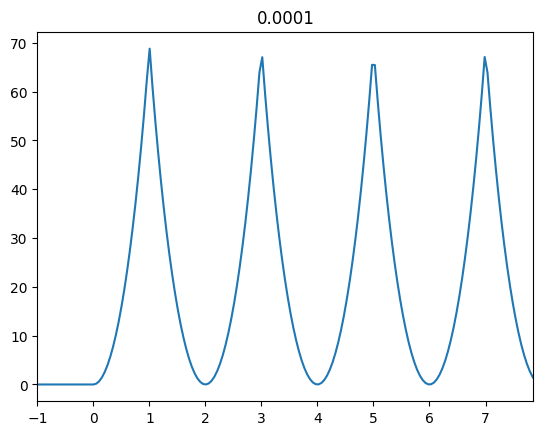

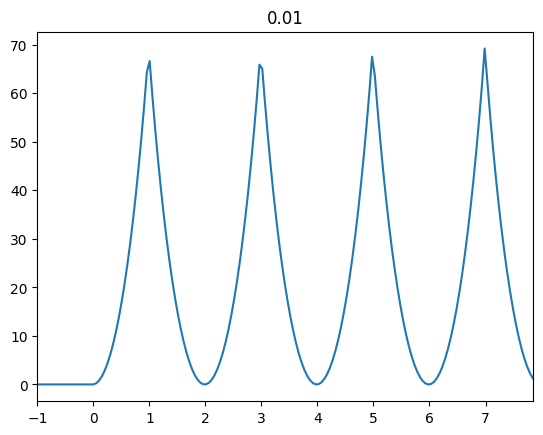

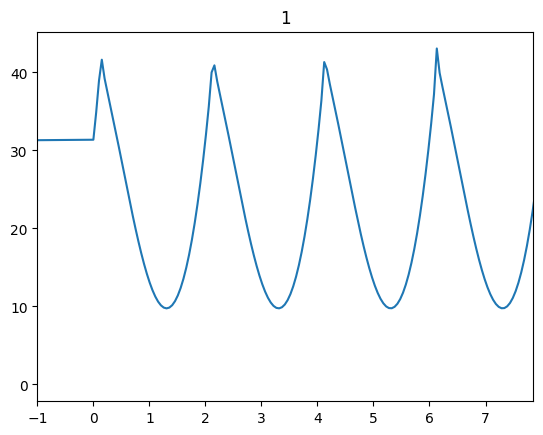

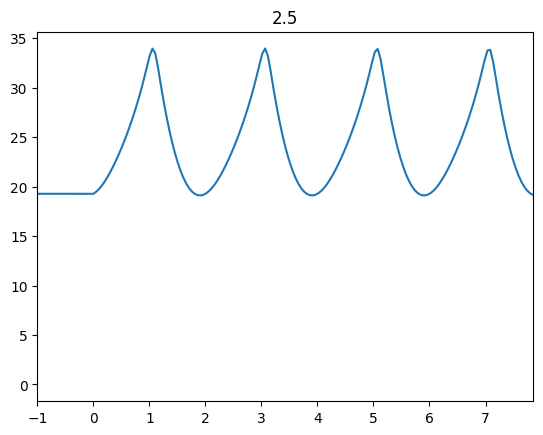

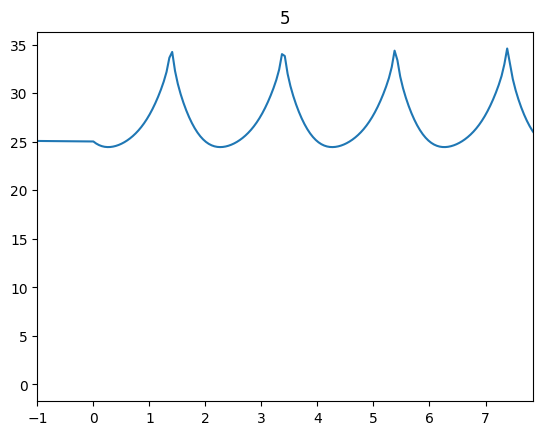

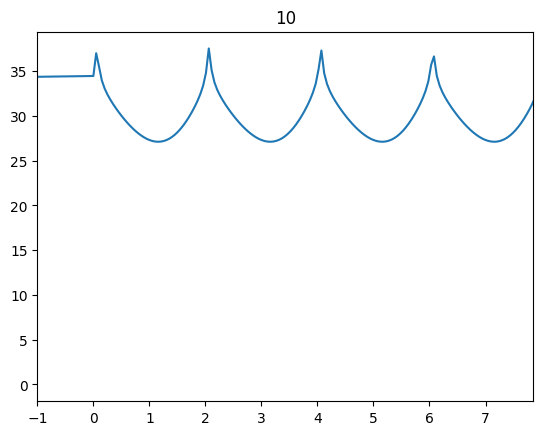

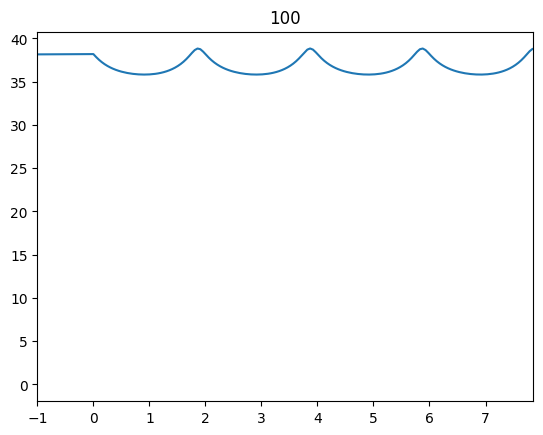

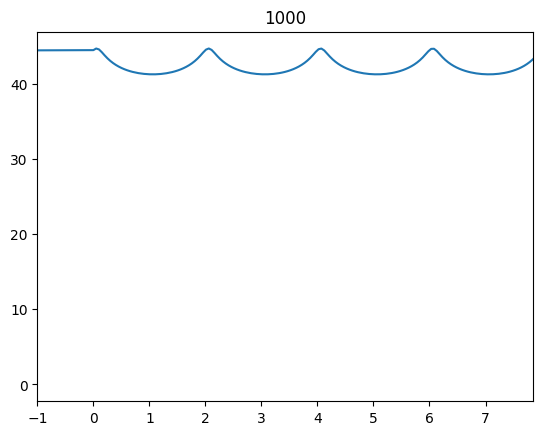

In [409]:
for s,friend,tau in zip(slow_protocol_states,sudden_protocol_states,quench_times):
    plot(t_plot/t_c,-log(nq.overlap(s,nq.groundstate(2,L))))
    #scatter(t_plot/t_c,nq.overlap(friend,nq.groundstate(2,L)),s=5)
    title(tau)
    xlim(-1,t_plot[-1])
    show()


